#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import os

from tqdm import tqdm
import itertools


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)

#Data Preparation

In [2]:
def make_dataset(path):
    data_path = path

    all_paths = []
    all_labels = []


    all_folders = os.listdir(data_path)

    for folder in all_folders:

        folder_path = os.path.join(data_path , folder)

        all_imgs = os.listdir(folder_path)

        for img in all_imgs:
            image_path = os.path.join(folder_path,img)

            all_paths.append(image_path)

            all_labels.append(folder)


    paths = pd.Series(all_paths, name = "img_path")
    labels = pd.Series(all_labels, name = "img_label")

    return pd.concat([paths, labels], axis=1)

In [4]:
training_data = make_dataset(r'/content/drive/MyDrive/MRI Detection/dataset/Training')
training_data

,img_path,img_label
0,/content/drive/MyDrive/MRI Detection/dataset/T...,meningioma
1,/content/drive/MyDrive/MRI Detection/dataset/T...,meningioma
2,/content/drive/MyDrive/MRI Detection/dataset/T...,meningioma
3,/content/drive/MyDrive/MRI Detection/dataset/T...,meningioma
4,/content/drive/MyDrive/MRI Detection/dataset/T...,meningioma
...,...,...
5595,/content/drive/MyDrive/MRI Detection/dataset/T...,notumor
5596,/content/drive/MyDrive/MRI Detection/dataset/T...,notumor
5597,/content/drive/MyDrive/MRI Detection/dataset/T...,notumor
5598,/content/drive/MyDrive/MRI Detection/dataset/T...,notumor


In [5]:
testing_data = make_dataset(r'/content/drive/MyDrive/MRI Detection/dataset/Testing')
testing_data

,img_path,img_label
0,/content/drive/MyDrive/MRI Detection/dataset/T...,pituitary
1,/content/drive/MyDrive/MRI Detection/dataset/T...,pituitary
2,/content/drive/MyDrive/MRI Detection/dataset/T...,pituitary
3,/content/drive/MyDrive/MRI Detection/dataset/T...,pituitary
4,/content/drive/MyDrive/MRI Detection/dataset/T...,pituitary
...,...,...
1595,/content/drive/MyDrive/MRI Detection/dataset/T...,glioma
1596,/content/drive/MyDrive/MRI Detection/dataset/T...,glioma
1597,/content/drive/MyDrive/MRI Detection/dataset/T...,glioma
1598,/content/drive/MyDrive/MRI Detection/dataset/T...,glioma


In [7]:
valid_df, test_df = train_test_split(testing_data, train_size=0.5, shuffle= True, random_state=42)

#Data Pipeline

In [8]:
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 16
img_size = (380, 380)

tr_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = tr_gen.flow_from_dataframe(
    training_data,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_generator = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

test_generator = ts_gen.flow_from_dataframe(
    test_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [9]:
training_data.shape

(5600, 2)

In [10]:
testing_data.shape

(1600, 2)

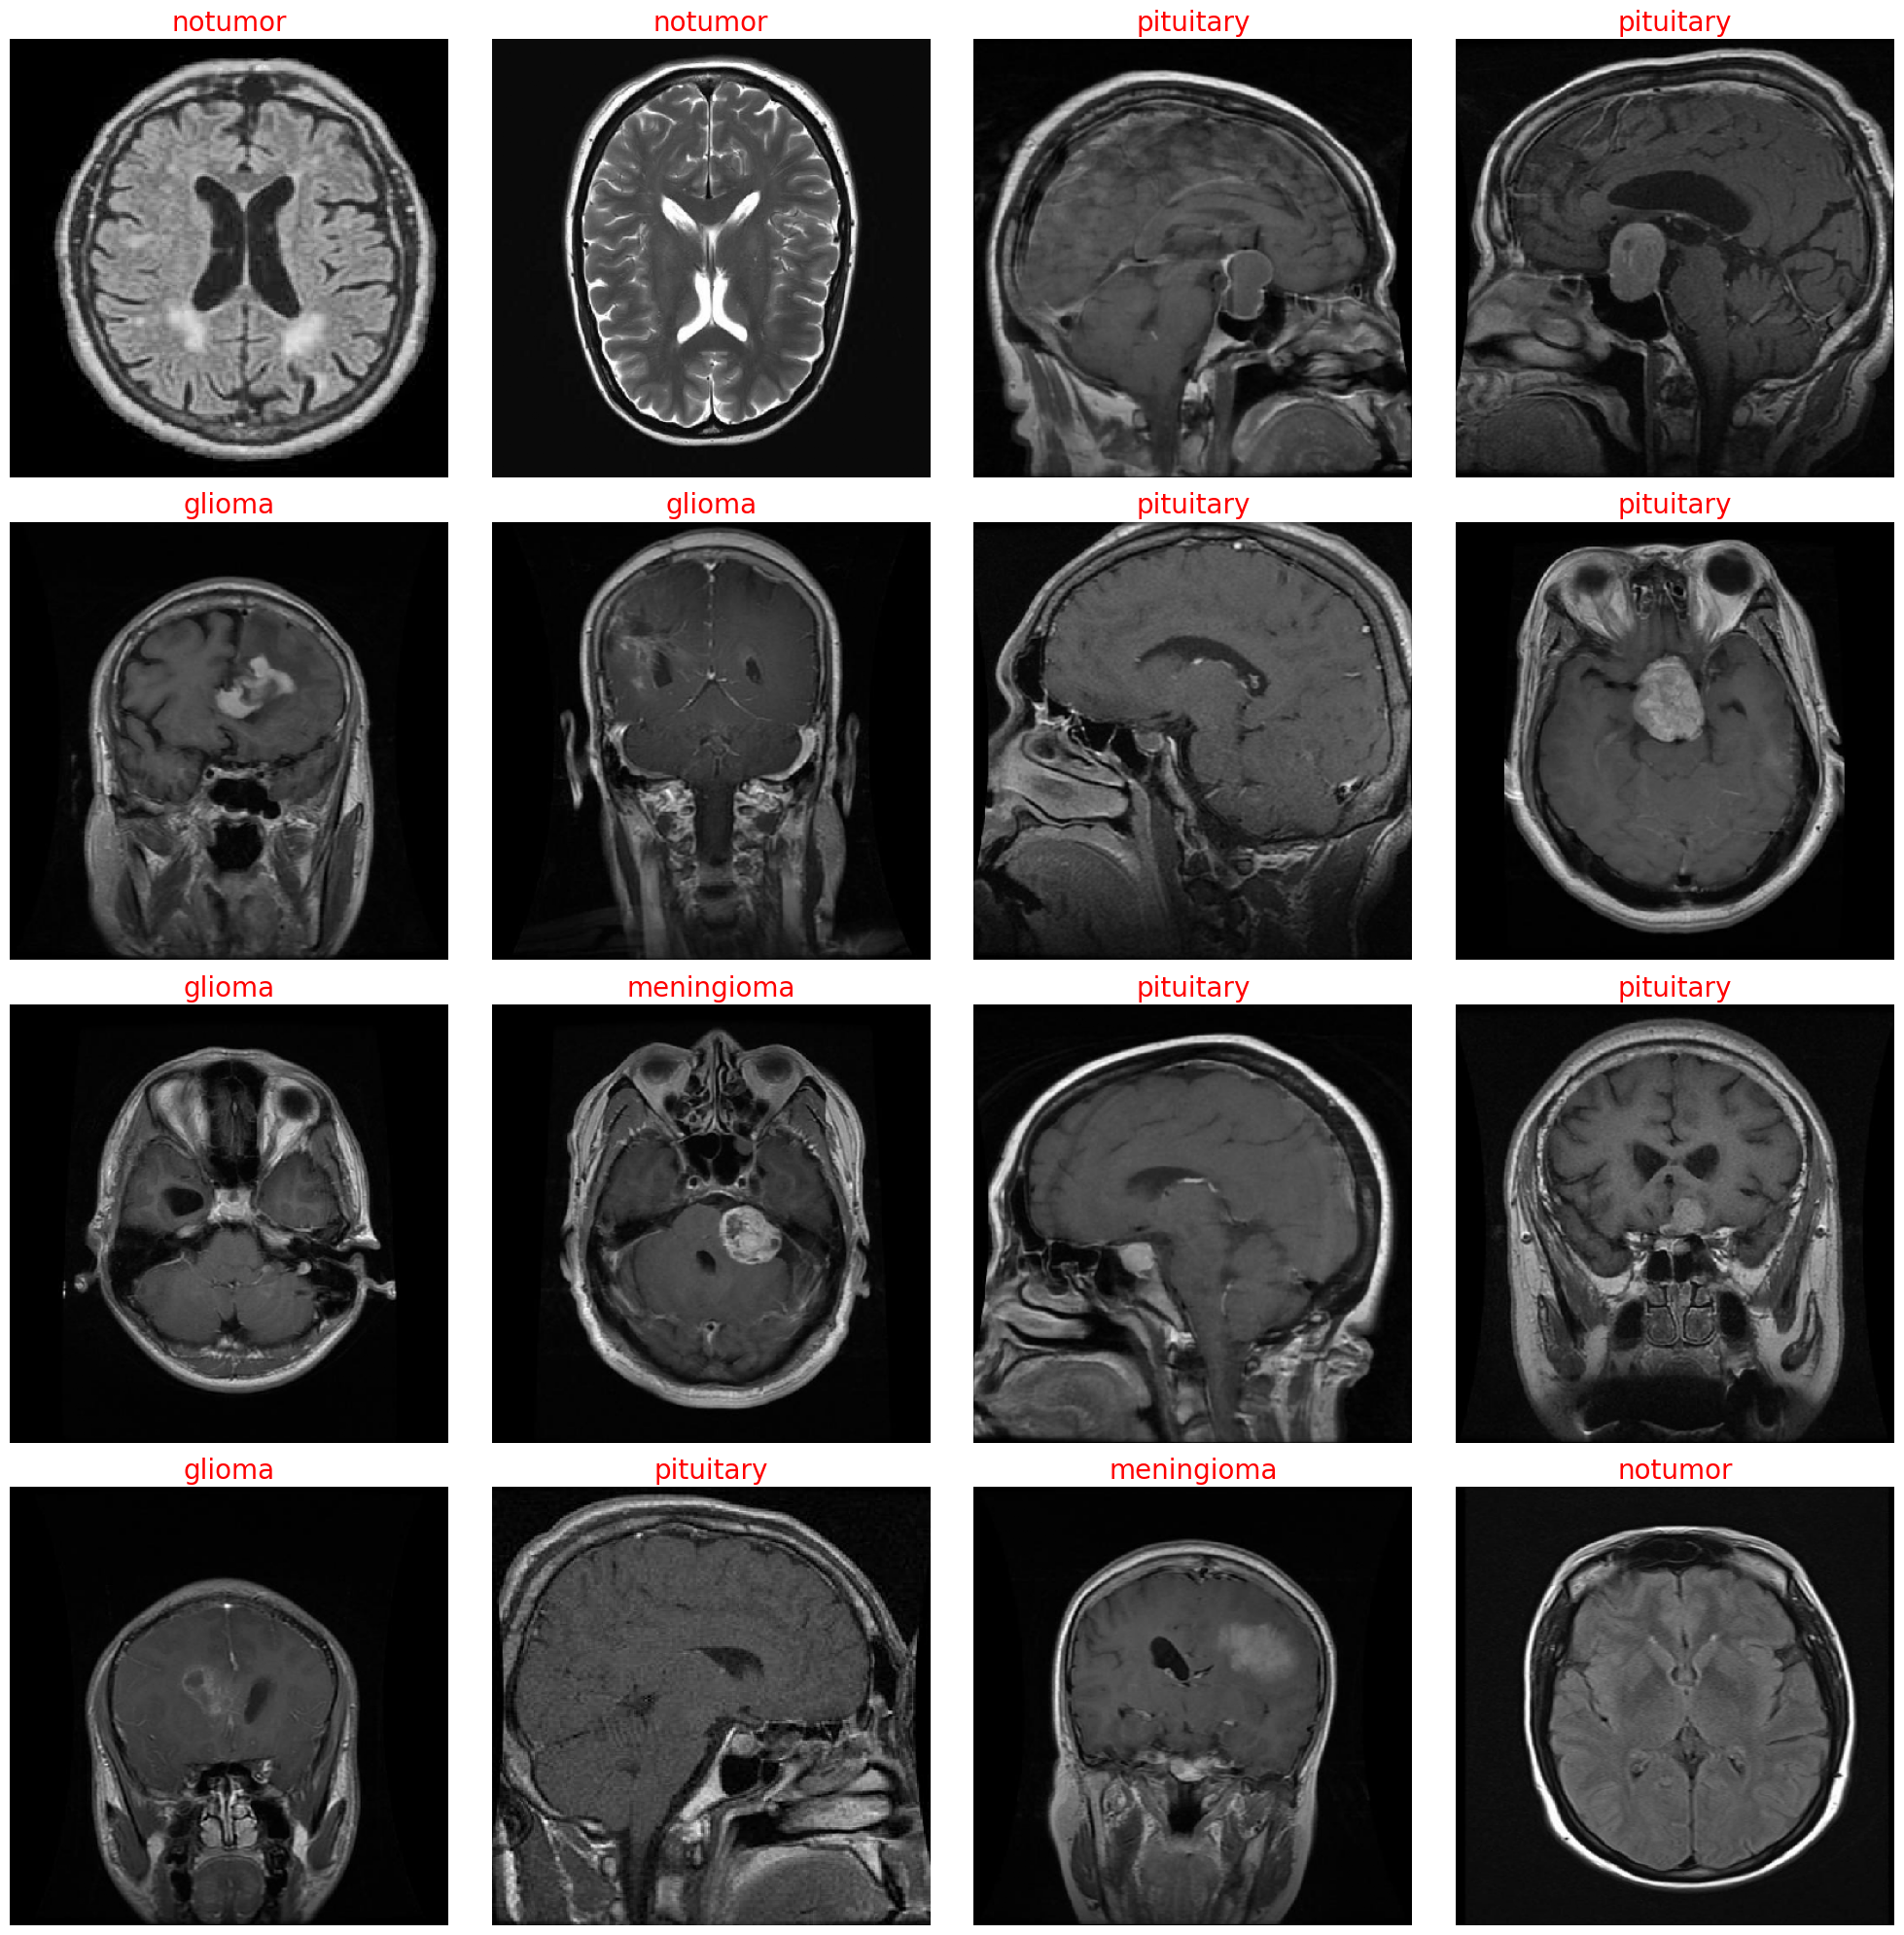

In [11]:
gen_dict = train_generator.class_indices
classes = list(gen_dict.keys())

images, labels = next(train_generator)

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    image = images[i] / 255.0

    # Display the image
    plt.imshow(image , cmap='gray')

    index = np.argmax(labels[i])
    class_name = classes[index]

    plt.title(class_name, color='red', fontsize=20)
    plt.axis('off')

plt.tight_layout()
plt.show()

#Model Architecture

In [12]:
img_shape = (img_size[0], img_size[1] ,3)
class_count = len(list(train_generator.class_indices.keys()))

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    base_model = keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_shape=(380, 380, 3),
        pooling='max',
    )
    base_model.trainable = False

    model = Sequential([
        base_model,
        BatchNormalization(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,174,947 (69.33 MB)

 Trainable params: 496,772 (1.90 MB)

 Non-trainable params: 17,678,175 (67.44 MB)

#Training

In [13]:
print("🔓 Phase : Transfer Learning with freeze weights")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=40,
    verbose=1,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping , reduce_lr]
)

🔓 Phase : Transfer Learning with freeze weights


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 1921s 5s/step - accuracy: 0.7130 - loss: 0.8102 - val_accuracy: 0.8637 - val_loss: 0.4715 - learning_rate: 0.0010
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 112s 319ms/step - accuracy: 0.8535 - loss: 0.3958 - val_accuracy: 0.8788 - val_loss: 0.4391 - learning_rate: 0.0010
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 318ms/step - accuracy: 0.8922 - loss: 0.3000 - val_accuracy: 0.8925 - val_loss: 0.3933 - learning_rate: 0.0010
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.8968 - loss: 0.2755 - val_accuracy: 0.8938 - val_loss: 0.3897 - learning_rate: 0.0010
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.9140 - loss: 0.2279 - val_accuracy: 0.9137 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.9114 - loss: 0.2397 - val_accuracy: 0.8950 - val_loss: 0.4173 - learning_rate: 0.0010
Epoch 7/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 318ms/step - accuracy

#Fine Tune

In [14]:
print("🔓 Phase 2: Fine-tuning entire model")

with strategy.scope():
    base_model.trainable = True  # Unfreeze EfficientNet

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_phase2 = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)

🔓 Phase 2: Fine-tuning entire model
Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.8180 - loss: 0.6483 - val_accuracy: 0.8000 - val_loss: 0.7921 - learning_rate: 1.0000e-04
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 452s 1s/step - accuracy: 0.9382 - loss: 0.1717 - val_accuracy: 0.9287 - val_loss: 0.3846 - learning_rate: 1.0000e-04
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.9593 - loss: 0.1088 - val_accuracy: 0.9475 - val_loss: 0.2987 - learning_rate: 1.0000e-04
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.9709 - loss: 0.0821 - val_accuracy: 0.9475 - val_loss: 0.2840 - learning_rate: 1.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.9842 - loss: 0.0527 - val_accuracy: 0.9550 - val_loss: 0.3622 - learning_rate: 1.0000e-04
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.9826 - loss: 0.0477 - val_accuracy: 0.9500 - val_loss: 0.3252 - learning_rate: 1.0000e-04
Epoch 7/40
350/350 ━━━

#Result & Evaluation

In [ ]:
# Define needed variables
tr_acc = history_phase2.history['accuracy']
tr_loss = history_phase2.history['loss']
val_acc = history_phase2.history['val_accuracy']
val_loss = history_phase2.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 245s 5s/step - accuracy: 0.9655 - loss: 0.1951
Test Accuracy: 95.00%
Test Loss: 0.2475


In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes


class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

#Save Model

In [18]:
model.save('Pretrained_model.keras')
print("Saved model")

Saved model
